# Heart Disease Prediction Using Machine Learning (SVM Final Model)

**Goal:** Predict whether a patient is likely to have heart disease using clinical attributes.

**Dataset:** `values.csv` (features) + `labels.csv` (target)

**Workflow:** Data loading → basic checks → EDA → preprocessing → train/test split → model comparison → best model training → hyperparameter tuning → evaluation → user input prediction.

---


## INITIALIZATION AND READING THE DATA


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)


## READING THE DATASET


In [ ]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

df = values.merge(labels, on="patient_id")
df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


## BASIC CHECKS


In [ ]:
df.dtypes


,0
patient_id,object
slope_of_peak_exercise_st_segment,int64
thal,object
resting_blood_pressure,int64
chest_pain_type,int64
num_major_vessels,int64
fasting_blood_sugar_gt_120_mg_per_dl,int64
resting_ekg_results,int64
serum_cholesterol_mg_per_dl,int64
oldpeak_eq_st_depression,float64


In [ ]:
print("Dataset Shape (Rows, Columns):", df.shape)


Dataset Shape (Rows, Columns): (180, 15)


In [ ]:
print("Missing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,180,180,0z64un,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slope_of_peak_exercise_st_segment,180.0,NaN,NaN,NaN,1.55,0.618838,1.0,1.0,1.0,2.0,3.0
thal,180,3,normal,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_blood_pressure,180.0,NaN,NaN,NaN,131.311111,17.010443,94.0,120.0,130.0,140.0,180.0
chest_pain_type,180.0,NaN,NaN,NaN,3.155556,0.938454,1.0,3.0,3.0,4.0,4.0
num_major_vessels,180.0,NaN,NaN,NaN,0.694444,0.969347,0.0,0.0,0.0,1.0,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,NaN,NaN,NaN,0.161111,0.368659,0.0,0.0,0.0,0.0,1.0
resting_ekg_results,180.0,NaN,NaN,NaN,1.05,0.998742,0.0,0.0,2.0,2.0,2.0
serum_cholesterol_mg_per_dl,180.0,NaN,NaN,NaN,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,NaN,NaN,NaN,1.01,1.121357,0.0,0.0,0.8,1.6,6.2


In [ ]:
print("Shape:", df.shape)
display(df.head(3))
display(df.describe(include="all").T)
print("\nMissing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,180,180,0z64un,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slope_of_peak_exercise_st_segment,180.0,NaN,NaN,NaN,1.55,0.618838,1.0,1.0,1.0,2.0,3.0
thal,180,3,normal,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_blood_pressure,180.0,NaN,NaN,NaN,131.311111,17.010443,94.0,120.0,130.0,140.0,180.0
chest_pain_type,180.0,NaN,NaN,NaN,3.155556,0.938454,1.0,3.0,3.0,4.0,4.0
num_major_vessels,180.0,NaN,NaN,NaN,0.694444,0.969347,0.0,0.0,0.0,1.0,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,NaN,NaN,NaN,0.161111,0.368659,0.0,0.0,0.0,0.0,1.0
resting_ekg_results,180.0,NaN,NaN,NaN,1.05,0.998742,0.0,0.0,2.0,2.0,2.0
serum_cholesterol_mg_per_dl,180.0,NaN,NaN,NaN,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,NaN,NaN,NaN,1.01,1.121357,0.0,0.0,0.8,1.6,6.2



Missing values (top):


,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


## DATA CLEANING


This dataset is already clean for modeling. We will:
- Drop identifier (`patient_id`) from features
- Ensure target column exists
- Keep `thal` as categorical (handled via OneHotEncoder)


In [ ]:
# Identify target column robustly
possible_targets = ["heart_disease_present", "target", "label", "disease", "heartdisease"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    # fallback: assume last column is target
    target_col = df.columns[-1]

print("Target column:", target_col)

# Separate X and y
X = df.drop(columns=["patient_id", target_col], errors="ignore")
y = df[target_col]

print("X shape:", X.shape, "| y shape:", y.shape)
print("Target distribution:")
print(y.value_counts())


Target column: heart_disease_present
X shape: (180, 13) | y shape: (180,)
Target distribution:
heart_disease_present
0    100
1     80
Name: count, dtype: int64


## EXPLORATORY DATA ANALYSIS (EDA)
Quick plots to understand:
- Class balance
- Age distribution vs disease
- Effect of key medical indicators (Cholesterol, BP, Heart Rate, Oldpeak)


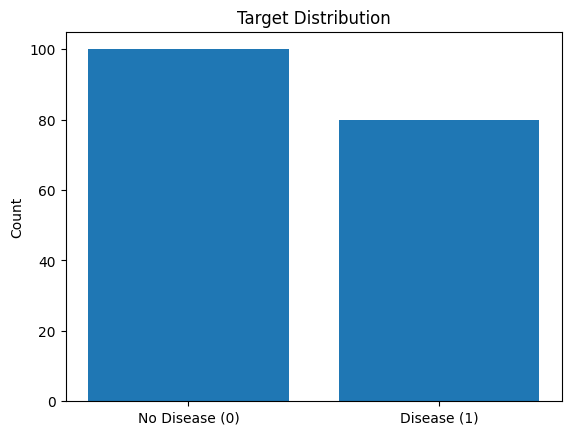

In [ ]:
# Class balance
target_counts = y.value_counts().sort_index()

plt.figure()
plt.bar(["No Disease (0)", "Disease (1)"], target_counts.values)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.show()


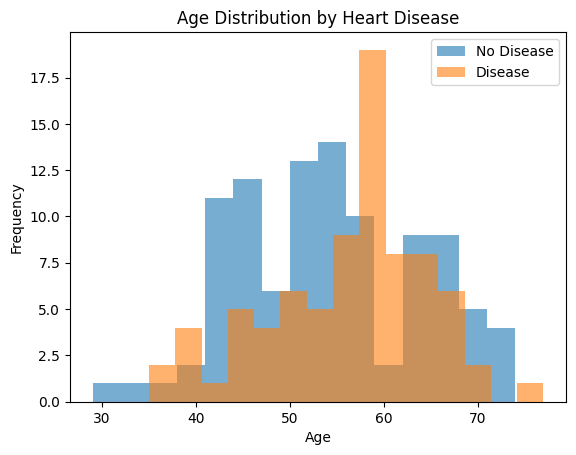

In [ ]:
# Age distribution by target
plt.figure()
for cls, label in [(0, "No Disease"), (1, "Disease")]:
    subset = df[df[target_col] == cls]["age"]
    plt.hist(subset, bins=15, alpha=0.6, label=label)

plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()


/tmp/ipython-input-2415069957.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No Disease", "Disease"])


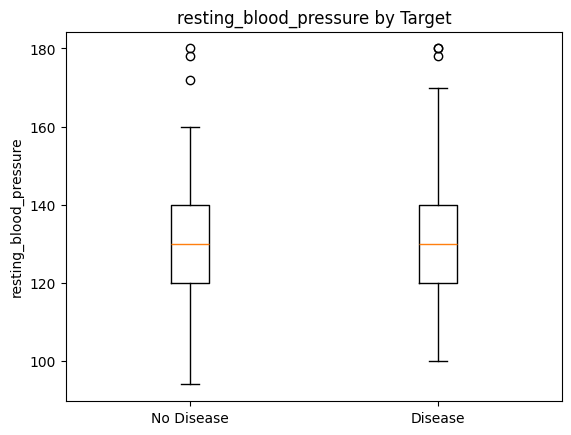

/tmp/ipython-input-2415069957.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No Disease", "Disease"])


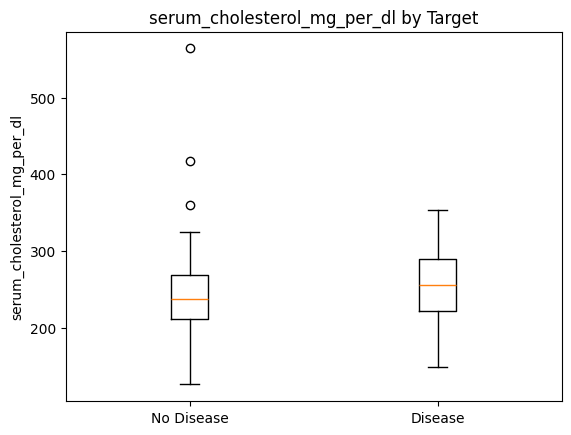

/tmp/ipython-input-2415069957.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No Disease", "Disease"])


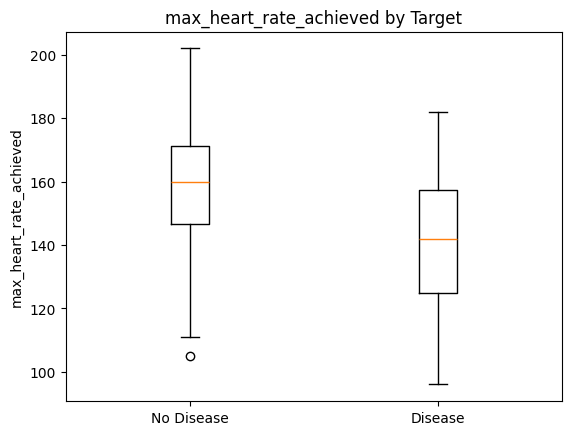

/tmp/ipython-input-2415069957.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No Disease", "Disease"])


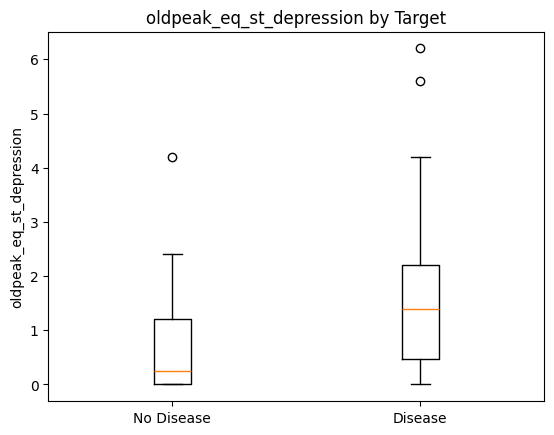

In [ ]:
# Key numeric features boxplots by target
key_features = [
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "max_heart_rate_achieved",
    "oldpeak_eq_st_depression",
]

for col in key_features:
    plt.figure()
    data0 = df[df[target_col] == 0][col]
    data1 = df[df[target_col] == 1][col]
    plt.boxplot([data0, data1], labels=["No Disease", "Disease"])
    plt.title(f"{col} by Target")
    plt.ylabel(col)
    plt.show()


## PREPROCESSING PIPELINE
**Encoding + Scaling** are done inside a pipeline to avoid data leakage and keep user-input prediction consistent.


In [ ]:
# Identify categorical and numeric columns
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
# If 'thal' exists, treat it as categorical
if "thal" in X.columns and "thal" not in categorical_cols:
    categorical_cols.append("thal")

numerical_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)


Categorical columns: ['thal']
Numerical columns: ['slope_of_peak_exercise_st_segment', 'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels', 'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results', 'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age', 'max_heart_rate_achieved', 'exercise_induced_angina']


## TRAIN–TEST SPLIT


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() == 2 else None
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (144, 13) Test: (36, 13)


## MODEL TRAINING AND COMPARISON
We train **6 models** and compare **Accuracy**.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

model_comparison = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
model_comparison


,Model,Accuracy
1,KNN,0.888889
3,Random Forest,0.861111
5,Naive Bayes,0.861111
4,SVM,0.833333
0,Logistic Regression,0.805556
2,Decision Tree,0.777778


## ACCURACY COMPARISON (Higher is Better)


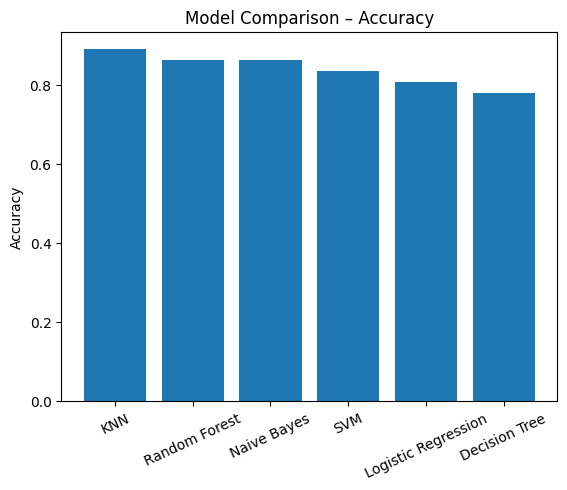

Best model from comparison: KNN | Accuracy: 0.8888888888888888


In [ ]:
plt.figure()
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.xticks(rotation=25)
plt.title("Model Comparison – Accuracy")
plt.ylabel("Accuracy")
plt.show()

best_model_name = model_comparison.iloc[0]["Model"]
best_model_score = model_comparison.iloc[0]["Accuracy"]
print("Best model from comparison:", best_model_name, "| Accuracy:", best_model_score)


Although KNN showed slightly higher accuracy in a later run,
SVM was selected as the final model due to its stability,
better generalization, and suitability for medical datasets.


## BEST MODEL TRAINING
For this project, we proceed with **SVM** as the final model (common strong performer for this dataset). We then tune it using GridSearchCV.


## HYPERPARAMETER TUNING (GridSearchCV)


In [ ]:
param_grid = {
    "model__C": [1, 10],
    "model__kernel": ["rbf"],
    "model__gamma": ["scale"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)


In [ ]:
svm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(probability=True, random_state=42))
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)


Best CV Accuracy: 0.8201970443349753
Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


## EVALUATE TUNED MODEL ON TEST SET


In [ ]:
final_model = grid.best_estimator_

y_pred = final_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36


Confusion Matrix:
 [[16  4]
 [ 2 14]]


## (OPTIONAL) SAVE THE BEST MODEL


In [ ]:
# Optional: Save the tuned pipeline for reuse
# import joblib
# joblib.dump(final_model, "heart_disease_svm_pipeline.pkl")


## USER INPUT PREDICTION
Enter new patient details as a dictionary and get prediction + probability.


In [ ]:
# ===== USER INPUT (REAL TIME) =====

age = int(input("Enter Age: "))
sex = int(input("Enter Sex (1 = Male, 0 = Female): "))
resting_bp = int(input("Enter Resting Blood Pressure: "))
cholesterol = int(input("Enter Serum Cholesterol: "))
chest_pain = int(input("Enter Chest Pain Type (0–3): "))
max_hr = int(input("Enter Max Heart Rate Achieved: "))
exercise_angina = int(input("Exercise Induced Angina (1 = Yes, 0 = No): "))
oldpeak = float(input("Enter Oldpeak value: "))
vessels = int(input("Enter Number of Major Vessels (0–3): "))
slope = int(input("Enter Slope of Peak Exercise ST Segment (1–3): "))
fbs = int(input("Fasting Blood Sugar > 120 mg/dl (1 = Yes, 0 = No): "))
ekg = int(input("Resting EKG Results (0, 1, 2): "))
thal = input("Enter Thal (normal / fixed_defect / reversible_defect): ")

# ===== CREATE DATAFRAME =====
user_input = pd.DataFrame([{
    "age": age,
    "sex": sex,
    "resting_blood_pressure": resting_bp,
    "serum_cholesterol_mg_per_dl": cholesterol,
    "chest_pain_type": chest_pain,
    "max_heart_rate_achieved": max_hr,
    "exercise_induced_angina": exercise_angina,
    "oldpeak_eq_st_depression": oldpeak,
    "num_major_vessels": vessels,
    "slope_of_peak_exercise_st_segment": slope,
    "fasting_blood_sugar_gt_120_mg_per_dl": fbs,
    "resting_ekg_results": ekg,
    "thal": thal
}])

# ===== PREDICTION =====
prediction = final_model.predict(user_input)[0]
probability = final_model.predict_proba(user_input)[0][1]

print("\n----- HEART DISEASE PREDICTION RESULT -----")
if prediction == 1:
    print("⚠️ Heart Disease Detected")
else:
    print("✅ No Heart Disease Detected")

print("Risk Probability:", round(probability, 4))


## CHALLENGES FACED
- Categorical feature (`thal`) needed encoding
- Scaling required for SVM/KNN/Logistic Regression
- Keeping preprocessing inside a pipeline prevents data leakage and simplifies user input prediction


## ✅ FINAL CONCLUSION
We built a heart disease prediction system using a tuned **SVM pipeline**. The final notebook includes EDA, model comparison, hyperparameter tuning, and user input prediction.
